In [ ]:
import pandas as pd
from sklearn.utils import shuffle
import re
import string
import numpy as np
from collections import Counter
import math


In [ ]:

def load_data(file_path):
  df = pd.read_csv(file_path)
  print(df.head())
  df_shuffled = shuffle(df, random_state=42).reset_index(drop=True)
  print(df_shuffled['label'].value_counts())
  return df_shuffled



In [ ]:
#clickbaits,
#COVID misinformation,
#real COVID news,
#political misinformation,
#political real news

In [ ]:
df = load_data('/content/shuffled_news (2).csv')


                                            subject                      label
0             Pigeons Love Wearing Bagels Apparently                clickbaits
1             For Anyone Who Still Uses A Nightlight                clickbaits
2  NEW YORK (Reuters) - Democrat Hillary Clinton ...              politicsNews
3  (Reuters) - The chairman of Democrat Hillary C...              politicsNews
4  In March 2015, only months after Detroit emerg...  political misinformation
label
covid misinformation        210
clickbaits                  149
politicsNews                149
covid news                  145
political misinformation    125
Name: count, dtype: int64


In [ ]:

stopwords = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'while', 'with', 'without',
    'to', 'from', 'by', 'of', 'on', 'in', 'for', 'as', 'at', 'this', 'that',
    'these', 'those', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them',
    'he', 'she', 'his', 'her', 'you', 'we', 'i', 'me', 'my', 'our', 'us',
    'their', 'there', 'what', 'which', 'who', 'whom', 'why', 'how', 'not',
    'no', 'yes', 'can', 'will', 'just', 'should', 'would', 'could', 'up',
    'down', 'out', 'over', 'under', 'again', 'about', 'into', 'then',
    'more', 'only', 'than', 'all', 'so', 'too', 'very', 'must', 'such','your','s'
}

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stopwords]

    cleaned = ' '.join(tokens)

    return cleaned.strip()



In [ ]:
#df = pd.read_csv('shuffled_news.csv')
df['clean_text'] = df['subject '].apply(clean_text)

df.to_csv('cleaned_news.csv', index=False)

# sample
print(df[['subject ', 'clean_text', 'label']].head())


                                            subject   \
0      23 People Who Should Not Have Tweeted In 2015   
1  (Reuters) - Parliamentary elections in Septemb...   
2  Walmart has adopted staggered shopping days ba...   
3  (Reuters) - A longtime political adviser to Hi...   
4  CDC admitted to lying about COVID-19 death stats.   

                                          clean_text                 label  
0                             23 people tweeted 2015            clickbaits  
1  reuters parliamentary elections september show...          politicsNews  
2  walmart adopted staggered shopping days based ...  covid misinformation  
3  reuters longtime political adviser hillary cli...          politicsNews  
4             cdc admitted lying covid19 death stats  covid misinformation  


In [ ]:

#  Build vocabulary
def build_vocabulary(texts):
    vocab = set()
    for text in texts:
        words = text.split()
        vocab.update(words)
    return sorted(list(vocab))

#  Compute document frequency for each word
def compute_document_frequency(texts, vocab):
    df = dict.fromkeys(vocab, 0)
    for text in texts:
        words = set(text.split())
        for word in words:
            if word in vocab:
                df[word] += 1
    return df

#  Compute TF-IDF vector for each document
def compute_tfidf(texts, vocab, df, N):
    tfidf_matrix = []

    for text in texts:
        word_counts = Counter(text.split())
        total_words = sum(word_counts.values())
        tfidf_vector = []

        for word in vocab:
            tf = word_counts[word] / total_words if word in word_counts else 0
            idf = math.log(N / (1 + df[word]))  # adding 1 to avoid div by zero
            tfidf = tf * idf
            tfidf_vector.append(tfidf)

        tfidf_matrix.append(tfidf_vector)

    return np.array(tfidf_matrix)



In [ ]:
texts = df['clean_text'].tolist() #use 'clean_text' column as it is the data after preproceesing
labels = df['label'].tolist()
N = len(texts)

vocab = build_vocabulary(texts)
df_counts = compute_document_frequency(texts, vocab)
X_tfidf = compute_tfidf(texts, vocab, df_counts, N)
y = np.array(labels)

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (778, 12133)


In [ ]:
print(vocab)

['00018', '006', '00s', '01', '0100', '02', '024', '03', '0311', '08941', '09', '1', '10', '100', '1000', '10000', '100000', '1026', '10704', '108', '10finessed', '10point', '10second', '10to1', '10yearold', '10yearoldmelania', '11', '1100mile', '11116', '112', '115000', '11563931', '118', '1195', '11point', '11related', '11we', '11yearold', '12', '120', '1200', '1200mile', '125000', '126', '12nation', '12point', '13', '130', '13124', '1336', '135', '14', '140', '1419', '145', '1461', '14day', '14th', '14yearold', '15', '150', '1500', '15000', '1507', '1518', '152', '153', '153504', '1551', '157', '15minute', '15th', '15yearold', '16', '160', '1600', '1605', '160member', '1680', '1695', '16monthold', '17', '170', '1700', '17500', '1770', '17yearold', '18', '180', '1800', '180000', '18003825277', '18007466373', '1800s', '1820', '1839', '185', '1869', '189', '18955', '18th', '18to34', '18year', '19', '190', '1912', '1918', '1930sera', '1933', '194', '1944', '1948', '195', '1950', '1950s'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_tfidf_words(X_tfidf, vocab, top_n=20):
    # Compute average TF-IDF for each word
    avg_tfidf_scores = np.mean(X_tfidf, axis=0)

    # Pair each word with its avg TF-IDF and sort
    word_tfidf_pairs = list(zip(vocab, avg_tfidf_scores))
    sorted_words = sorted(word_tfidf_pairs, key=lambda x: x[1], reverse=True)

    # Get top N words and their scores
    top_words, top_scores = zip(*sorted_words[:top_n])

    plt.figure(figsize=(12, 6))
    plt.bar(top_words, top_scores, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Words")
    plt.ylabel("Average TF-IDF Score")
    plt.title(f"Top {top_n} Informative Words by Average TF-IDF")
    plt.tight_layout()
    plt.show()


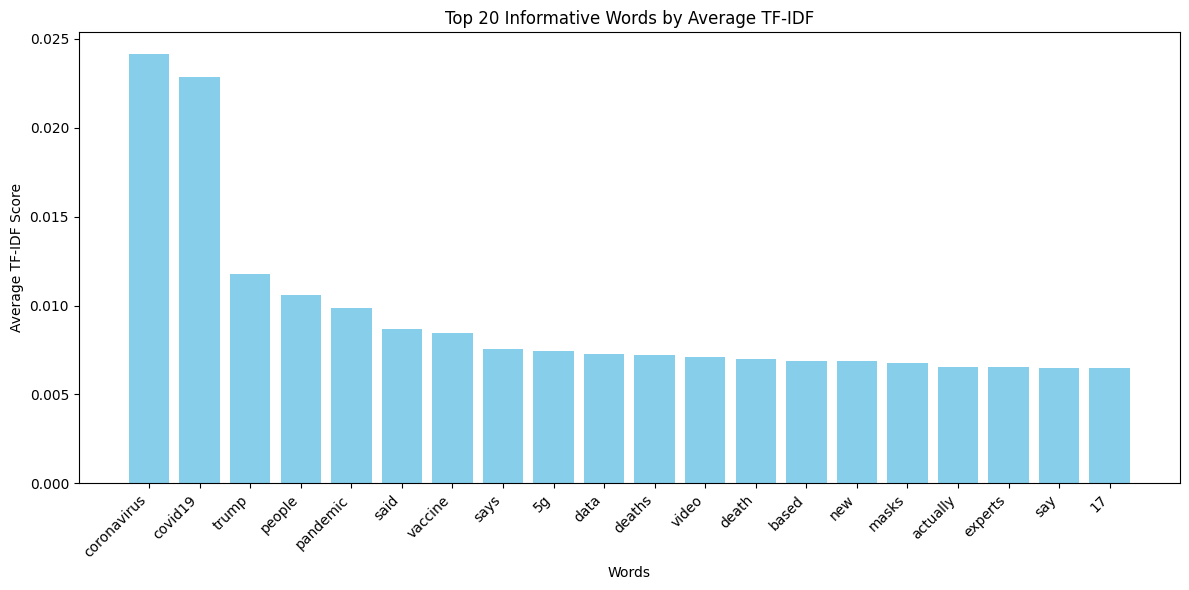

In [ ]:
plot_top_tfidf_words(X_tfidf, vocab, top_n=20)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_top_words_per_class(texts, labels, vocab, df_counts, X_tfidf, top_n=10):
    # Step 1: Create a mapping from class → indices
    class_indices = defaultdict(list)
    for i, label in enumerate(labels):
        class_indices[label].append(i)

    N = len(texts)  # total documents

    for cls, indices in class_indices.items():
        # Extract TF-IDF vectors for this class
        class_tfidf_vectors = X_tfidf[indices]
        # Compute average TF-IDF per word for the class
        avg_tfidf = np.mean(class_tfidf_vectors, axis=0)

        # Sort words by importance
        top_indices = np.argsort(avg_tfidf)[-top_n:][::-1]  # top N indices
        top_words = [vocab[i] for i in top_indices]
        top_scores = avg_tfidf[top_indices]

        plt.figure(figsize=(10, 4))
        plt.bar(top_words, top_scores, color='salmon')
        plt.xticks(rotation=45, ha='right')
        plt.title(f"Top {top_n} TF-IDF Words for Class: {cls}")
        plt.xlabel("Words")
        plt.ylabel("Avg TF-IDF Score")
        plt.tight_layout()
        plt.show()


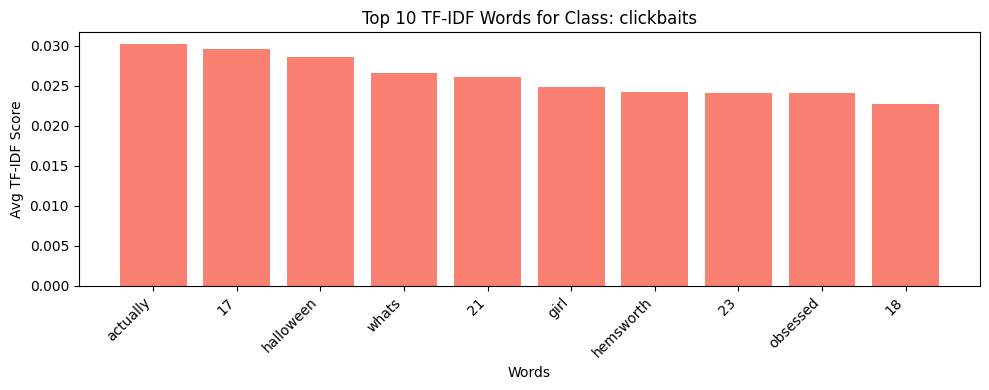

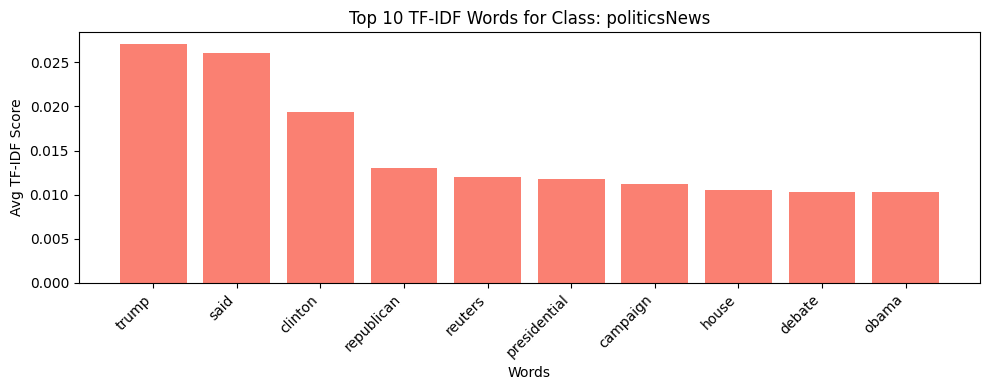

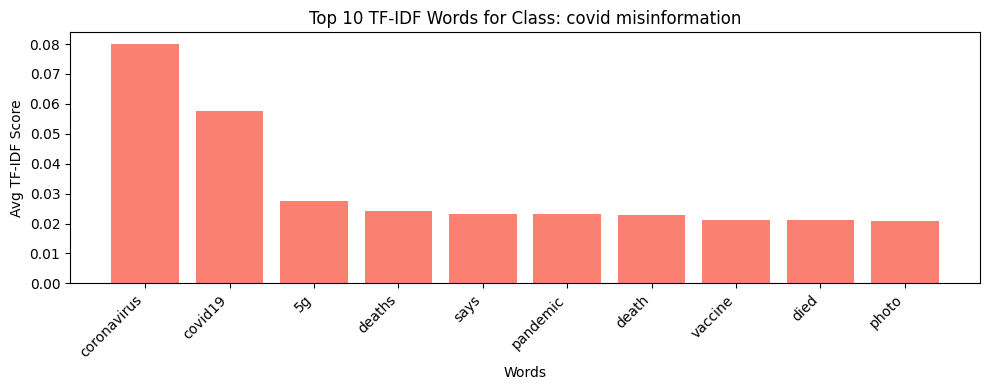

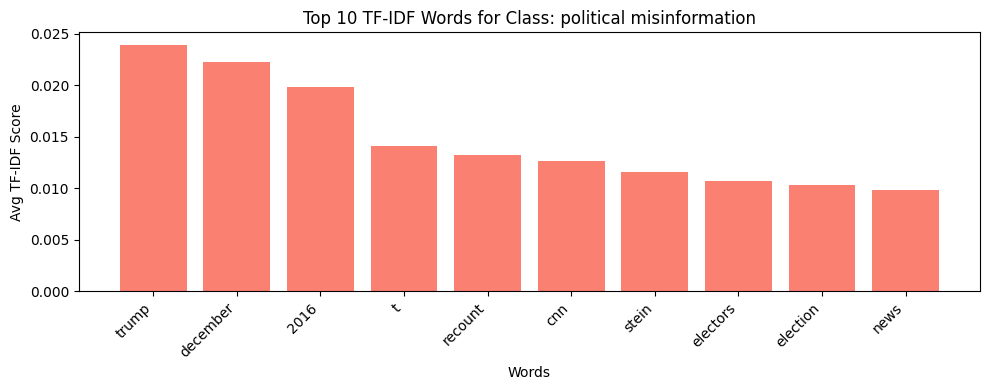

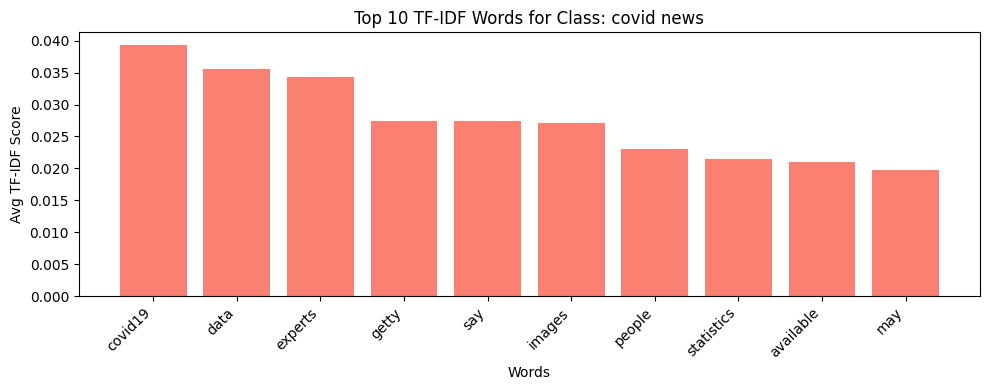

In [ ]:
plot_top_words_per_class(texts, labels, vocab, df_counts, X_tfidf, top_n=10)

In [ ]:
# y label encoding
# Unique classes
unique_classes = sorted(list(set(labels)))

# Create mapping: class name → index
label_to_index = {label: idx for idx, label in enumerate(unique_classes)}

# Apply encoding
y = [label_to_index[label] for label in labels]


In [ ]:
print(y)

[0, 4, 1, 4, 1, 0, 1, 0, 0, 0, 0, 1, 4, 1, 4, 1, 3, 2, 4, 2, 4, 4, 1, 2, 0, 3, 1, 1, 2, 2, 0, 3, 2, 4, 0, 1, 1, 0, 0, 4, 1, 4, 2, 4, 3, 1, 2, 3, 1, 4, 4, 0, 3, 2, 0, 0, 1, 2, 2, 4, 1, 1, 0, 2, 3, 4, 4, 1, 2, 1, 4, 2, 0, 2, 2, 4, 2, 2, 1, 0, 1, 4, 0, 3, 1, 0, 1, 4, 0, 0, 2, 3, 0, 1, 0, 3, 1, 1, 3, 2, 3, 0, 1, 2, 1, 1, 1, 2, 4, 1, 1, 3, 3, 1, 0, 4, 3, 4, 1, 2, 0, 0, 3, 4, 3, 1, 1, 2, 1, 0, 2, 0, 1, 1, 0, 3, 1, 4, 1, 4, 4, 3, 3, 4, 0, 1, 1, 2, 0, 0, 3, 0, 0, 2, 0, 0, 4, 3, 4, 1, 1, 1, 0, 0, 4, 1, 1, 1, 1, 3, 0, 1, 2, 2, 2, 4, 3, 2, 0, 2, 0, 3, 0, 2, 0, 1, 2, 0, 1, 3, 4, 0, 4, 0, 0, 1, 4, 2, 1, 2, 0, 3, 1, 3, 4, 1, 1, 3, 3, 2, 4, 4, 3, 0, 0, 4, 2, 1, 3, 2, 0, 1, 2, 4, 3, 2, 2, 0, 2, 4, 2, 4, 1, 4, 2, 1, 1, 2, 4, 2, 1, 3, 2, 1, 3, 2, 2, 0, 0, 1, 4, 2, 1, 3, 2, 3, 2, 2, 2, 4, 4, 4, 4, 3, 4, 4, 4, 4, 1, 3, 0, 2, 1, 1, 2, 2, 3, 4, 1, 3, 2, 2, 1, 4, 0, 0, 3, 4, 0, 2, 3, 1, 0, 2, 2, 1, 1, 3, 1, 3, 3, 1, 2, 3, 0, 4, 2, 2, 3, 4, 3, 1, 1, 1, 0, 2, 3, 1, 0, 3, 4, 3, 4, 3, 0, 0, 4, 4, 4, 1, 4, 1, 4, 

In [ ]:
# Convert X and y to NumPy arrays
X = np.array(X_tfidf)
y = np.array(y)

# Shuffle the data
indices = np.arange(len(X))
np.random.seed(42)
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

# Split
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


In [ ]:
print(X_train.shape)
print(np.max(X_train), np.min(X_train))
print(np.unique(y_train))
print(X_test.shape)

(622, 12133)
2.981789671809223 0.0
[0 1 2 3 4]
(156, 12133)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def compute_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm


In [ ]:
class LogisticRegressionScratch:
    def __init__(self, num_features, num_classes, learning_rate=0.1, epochs=1000):
        self.num_features = num_features
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.W = np.zeros((num_features, num_classes))
        self.b = np.zeros((1, num_classes))

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def _cross_entropy(self, probs, Y):
        return -np.mean(np.sum(Y * np.log(probs + 1e-15), axis=1))

    def train(self, X_train, y_train, X_val, y_val):
        m = X_train.shape[0]
        Y_train = one_hot_encode(y_train, self.num_classes)
        Y_val = one_hot_encode(y_val, self.num_classes)

        for epoch in range(1, self.epochs + 1):
            # Forward pass (train)
            logits = np.dot(X_train, self.W) + self.b
            probs = softmax(logits)
            train_loss = self._cross_entropy(probs, Y_train)
            train_preds = np.argmax(probs, axis=1)
            train_acc = accuracy(y_train, train_preds)

            # Backward pass
            dW = (1 / m) * np.dot(X_train.T, (probs - Y_train))
            db = (1 / m) * np.sum(probs - Y_train, axis=0, keepdims=True)

            # Update parameters
            self.W -= self.learning_rate * dW
            self.b -= self.learning_rate * db

            # Validation
            val_logits = np.dot(X_val, self.W) + self.b
            val_probs = softmax(val_logits)
            val_loss = self._cross_entropy(val_probs, Y_val)
            val_preds = np.argmax(val_probs, axis=1)
            val_acc = accuracy(y_val, val_preds)

            # Store metrics
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)

            # Print every 50 epochs
            if epoch % 50 == 0 or epoch == 1:
                print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    def predict(self, X):
        logits = np.dot(X, self.W) + self.b
        probs = softmax(logits)
        return np.argmax(probs, axis=1)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=500)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [ ]:
print(X_train.shape)

(622, 12133)


In [ ]:

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = LogisticRegressionScratch(num_features=num_features,
                                  num_classes=num_classes,
                                  learning_rate=0.9,
                                  epochs=850)

model.train(X_train, y_train, X_test, y_test)

# Final predictions and metrics
y_pred = model.predict(X_test)
final_test_acc = accuracy(y_test, y_pred)
print(f"\nFinal Test Accuracy: {final_test_acc:.4f}")


Epoch    1 | Train Loss: 1.6094 | Val Loss: 1.6007 | Train Acc: 0.1801 | Val Acc: 0.3205
Epoch   50 | Train Loss: 1.4504 | Val Loss: 1.5048 | Train Acc: 0.3682 | Val Acc: 0.3333
Epoch  100 | Train Loss: 1.3246 | Val Loss: 1.4385 | Train Acc: 0.7460 | Val Acc: 0.5705
Epoch  150 | Train Loss: 1.2185 | Val Loss: 1.3828 | Train Acc: 0.8424 | Val Acc: 0.6538
Epoch  200 | Train Loss: 1.1281 | Val Loss: 1.3353 | Train Acc: 0.8585 | Val Acc: 0.7051
Epoch  250 | Train Loss: 1.0501 | Val Loss: 1.2944 | Train Acc: 0.8714 | Val Acc: 0.7051
Epoch  300 | Train Loss: 0.9821 | Val Loss: 1.2587 | Train Acc: 0.8794 | Val Acc: 0.7051
Epoch  350 | Train Loss: 0.9224 | Val Loss: 1.2272 | Train Acc: 0.8891 | Val Acc: 0.7051
Epoch  400 | Train Loss: 0.8694 | Val Loss: 1.1993 | Train Acc: 0.8987 | Val Acc: 0.7051
Epoch  450 | Train Loss: 0.8222 | Val Loss: 1.1744 | Train Acc: 0.9051 | Val Acc: 0.7179
Epoch  500 | Train Loss: 0.7799 | Val Loss: 1.1520 | Train Acc: 0.9180 | Val Acc: 0.7179
Epoch  550 | Train Lo

In [ ]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='purple')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

def print_confusion_matrix(cm, num_classes):
    print("\nConfusion Matrix:")
    print("Predicted →")
    print("True ↓")
    print(cm)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()



Confusion Matrix:
Predicted →
True ↓
[[17  1  0  3 16]
 [ 0 40  1  1  8]
 [ 0  0 22  0  0]
 [ 0  0  0 11 13]
 [ 0  0  0  0 23]]


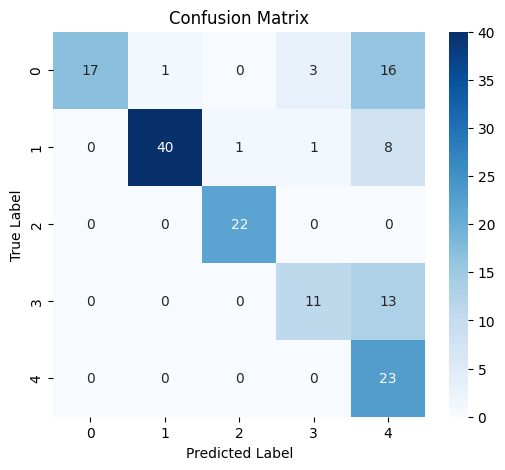

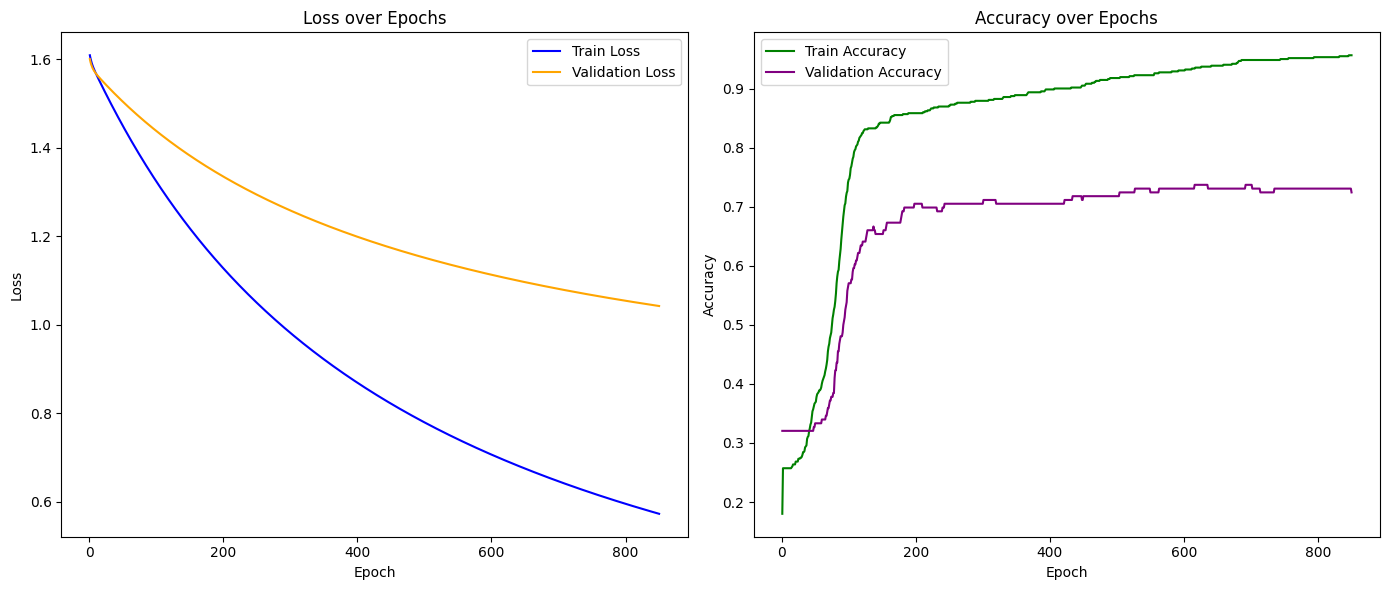

In [ ]:

cm = compute_confusion_matrix(y_test, y_pred, num_classes)
print_confusion_matrix(cm, num_classes)

# Plot training vs validation metrics
plot_metrics(model.train_losses, model.val_losses,
             model.train_accuracies, model.val_accuracies)
